# SVM linear em três dimensões

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Visualizar hiperplano, vetores de suporte e margem.

**Pergunta-guia:** Quais pontos determinam o hiperplano e o que muda ao alterar C?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

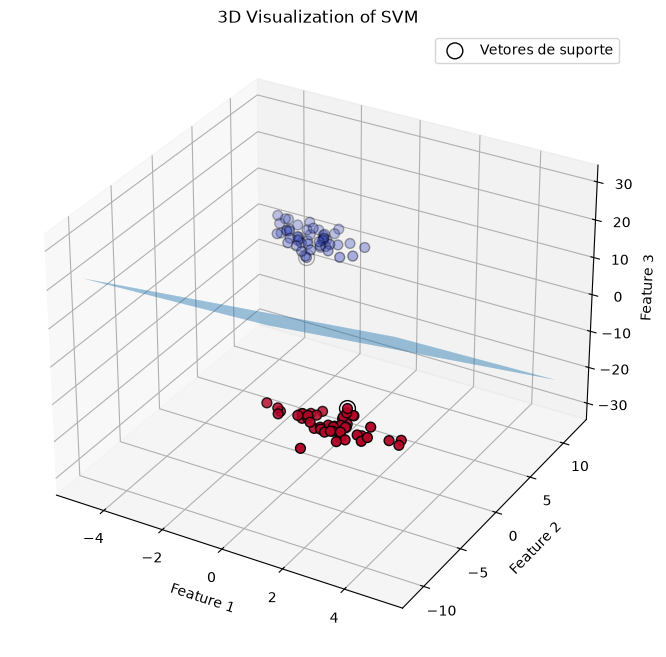

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs
from mpl_toolkits.mplot3d import Axes3D

# Gerar dados sintéticos para a visualização do SVM
X, y = make_blobs(n_samples=100, centers=2, n_features=3, random_state=42)

# Treinar o modelo SVM
model = svm.SVC(kernel='linear')
model.fit(X, y)

# Coeficientes para o hiperplano
coef = model.coef_[0]
intercept = model.intercept_

# Criar a grade para o hiperplano
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 50),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 50))

# Calcular os valores de z (terceira dimensão) para o hiperplano
zz = (-coef[0] * xx - coef[1] * yy - intercept) / coef[2]

# Plotar os dados e o hiperplano em 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='coolwarm', edgecolor='k', s=50)
ax.plot_surface(xx, yy, zz, alpha=0.5, shade=False)
ax.scatter(*model.support_vectors_.T, s=130, facecolors='none', edgecolors='black', label='Vetores de suporte')
ax.legend()
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
ax.set_title('3D Visualization of SVM')
plt.show()

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

In [2]:
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
for C in (0.1, 1, 10):
    comparacao = svm.SVC(kernel='linear', C=C).fit(X_treino, y_treino)
    print(f'C={C}: treino={comparacao.score(X_treino, y_treino):.2f}; teste={comparacao.score(X_teste, y_teste):.2f}; vetores de suporte={len(comparacao.support_vectors_)}')

C=0.1: treino=1.00; teste=1.00; vetores de suporte=2
C=1: treino=1.00; teste=1.00; vetores de suporte=2
C=10: treino=1.00; teste=1.00; vetores de suporte=2


## Interpretação e limites

A visualização usa dados de treino; inclua teste antes de afirmar generalização.

## Exercício

Avalie em treino e teste e teste `data/11.1 - dados_credito_svm.csv`.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.